In [1]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=False)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=100,adc_last_gap=100)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../chip_data/chip6_/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 55075
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


In [ ]:
v,c,r = chip.read4(crossbar=np.ones((10,10)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c0 = chip.compensation.compensation_point(r,from_row=True,return_type=0,)

v,c,r = chip.read4(crossbar=np.ones((10,10)),row_index=[i for i in range(10)],col_index=[i for i in range(10)],
                   read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)


compensation_para:dict={
"value":0.875,
"real_mean":550,
"odd_offset":0,
"even_offset":0,
"odd_mult":1,
"even_mult":1,
"all_mult":1,
"add_wire":False
}
cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
print(c.shape)
plt.plot(c[startpos:10])
plt.show()

### 1. 单列线性补偿

In [ ]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c = chip.compensation.compensation_point(r,from_row=True,return_type=0,)
# plot_cond(c,vmax=1000)

In [ ]:
compensation_para:dict={
"value":0.875,
"real_mean":550,
"odd_offset":0,
"even_offset":0,
"odd_mult":1,
"even_mult":1,
"all_mult":1,
"add_wire":False
}

c = chip.compensation.compensation_point(r,from_row=True,return_type=0,)

In [ ]:
col = 10
select_num,total_num = 50,200


random_times = 100
real_res = np.zeros(random_times)
expected_res = np.zeros(random_times)
for i in range(random_times):
    rows_index = np.random.choice(total_num, select_num, replace=False)
    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=[col],read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[num]))
    expected_res[i]=np.sum(c[rows_index,col])
    real_res[i]=cond[col]

In [ ]:
coefficients = np.polyfit(real_res, expected_res, 1)
print("拟合系数:", coefficients[num],coefficients[1])

# 拟合的线性函数
def linear_fit(x):
    return coefficients[num] * x + coefficients[1]

# 计算拟合的 y 值
y_fit = linear_fit(real_res)

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.title(f"random row count = {select_num}")
plt.plot(expected_res,label = "expected output")
plt.plot(real_res,label = "actual output")
plt.plot(y_fit,label = "fit output")
plt.ylabel("uS")
plt.xlabel("times")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.zeros(random_times))
plt.plot(real_res/expected_res-1,label = "actual output/expected output")
plt.plot(y_fit/expected_res-1,label = "fit output/expected output")
plt.ylabel("100%")
plt.xlabel("times")
plt.legend()
plt.title(f"random row count = {select_num}")
plt.show()

### 2. 矩阵求逆补偿

In [ ]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c = chip.compensation.compensation_point(r,from_row=True,return_type=0)

In [ ]:
col_index = [i for i in range(10,20)]
random_times = 5000
real_res = np.zeros((random_times,len(col_index)))
expected_res = np.zeros((random_times,len(col_index)))
for i in range(random_times):
    # 这次的输入是多少行
    row_num = np.random.choice(total_num, 1, replace=False)[num]
    while row_num ==0 :
        row_num = np.random.choice(total_num, 1, replace=False)[num]
    # 随机选row_num行作为输入
    rows_index = np.random.choice(total_num, row_num, replace=False)

    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[num]))
    pos = np.ix_(rows_index,col_index)
    # print(np.sum(c[pos],axis=0).shape)
    expected_res[i,:]=np.sum(c[pos],axis=0)
    real_res[i,:]=cond[col_index]

In [ ]:
rows_index = [i for i in range(10,20)]
random_times = 5000
real_res = np.zeros((random_times,len(rows_index)))
expected_res = np.zeros((random_times,len(rows_index)))
for i in range(random_times):
    # 这次的输入是多少行
    row_num = np.random.choice(total_num, 1, replace=False)[num]
    while row_num ==0 :
        row_num = np.random.choice(total_num, 1, replace=False)[num]
    # 随机选row_num行作为输入
    col_index = np.random.choice(total_num, row_num, replace=False)

    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # print(np.max(res[num]))
    pos = np.ix_(rows_index,col_index)
    # print(np.sum(c[pos],axis=0).shape)
    expected_res[i,:]=np.sum(c[pos],axis=1)
    real_res[i,:]=cond[rows_index]

In [ ]:
A_pinv = np.linalg.pinv(real_res)
W_pinv = np.dot(A_pinv,expected_res)
expected_res2 = np.dot(expected_res ,W_pinv)

data = expected_res2/expected_res-1
x = [i for i in range(10)]

In [ ]:
data = real_res/expected_res-1
data[data<-2] = -2
x = [i for i in range(10)]
for i in range(5000):
    plt.scatter(x, data[i], color='blue')
plt.plot(np.zeros(10))
# 添加标题和标签
plt.title("Y\'/Y")
plt.ylabel("100%")
plt.xlabel("col")

# 添加图例
# plt.legend()

# 显示图表
plt.show()

In [ ]:
print(np.sum(np.abs(data)>0.1)/50000)

### 3. 线阻补偿

In [3]:
v,c_expected_from_row,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c_expected_from_row = chip.compensation.compensation_point(r,from_row=True,return_type=0)

v,c_expected_from_col,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=0,row_type=0,col_type=0)
c_expected_from_col = chip.compensation.compensation_point(r,from_row=False,return_type=0)

In [4]:
compensation_para:dict={
"value":0.5,
"real_mean":550,
"odd_offset":0,
"even_offset":0,
"odd_mult":1,
"even_mult":1,
"all_mult":1,
"add_wire":False
}

In [5]:
print(chip.compensation.col_r_out_crossbar)

[[18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]
 [18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]
 [18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]
 ...
 [18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]
 [18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]
 [18.38867188 17.47070312 18.56445312 ... 20.20507812 19.97070312
  20.75195312]]


In [21]:
chip.compensation.initop("../chip_data/chip6_/")

In [6]:
# 10列，两路TIA并行
col_index = [i for i in range(256)]
# 存储数据
real_res = np.zeros((256,256))
real_cond_res = np.zeros((256,256))
expected_res = np.zeros((256,256))

for i in range(101):
    row_index = [j for j in range(i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(row_index,r,from_row=True,return_type=0,compensation_para=None)
    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_row[pos],axis=0)
    real_res[i,:]=r
    real_cond_res[i,:] = cond[col_index]

In [10]:
from scipy.stats import norm
from scipy.optimize import curve_fit

In [11]:
r_wire = chip.compensation.r_wire
r_out_col = chip.compensation.col_r_out
offset_col = chip.compensation.col_offset
# print(r_out_col)
def compensation_from_row(x,value,col):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if col%2==0 else i*r_wire
        r_out = r_out_col[col]
        # print(r_out,sum_rw)
        real_r = real_res[i,col]*1e3 -r_out -sum_rw + offset_col[col] - r_wire*(i**value)
        # print(value)
        # print(real_r)
        ans[i]=1/real_r*1e6
    # print(ans)
    return ans/expected_res[:rows,col]

n = 101
row_num = [i for i in range(n)]
ans = np.zeros(256)
value_col = np.zeros(256)

bounds = ([0], [1])
for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_from_row(x,value,i),row_num, expected_res[:n,i]/expected_res[:n,i], p0=[0.5],bounds=bounds)
    ans[i] = params[0]
    # value_col[i] = params[1]
    # print(params)
# print(value_col)
print(ans)

[1.00000000e+00 3.89881834e-06 9.99999999e-01 5.81392480e-01
 9.79455726e-01 7.15359033e-01 9.84126803e-01 8.61822043e-01
 9.91059408e-01 8.11169663e-01 9.82399754e-01 7.92898399e-01
 9.99999999e-01 6.90895320e-01 9.87984808e-01 7.16621199e-01
 1.00000000e+00 8.78537363e-01 9.73972504e-01 7.93778148e-01
 9.92269699e-01 8.01471253e-01 9.82961326e-01 7.38244786e-01
 9.72148740e-01 7.31921183e-01 9.77283593e-01 3.97664808e-01
 9.71545116e-01 7.82095528e-01 9.77095659e-01 7.14610963e-01
 9.56967363e-01 5.81562984e-01 9.41329736e-01 6.80540095e-01
 1.00000000e+00 6.44112769e-01 9.93489192e-01 7.95125606e-01
 9.60442523e-01 6.81531049e-01 9.72024451e-01 6.89637545e-01
 9.65019579e-01 8.22990961e-01 9.76832878e-01 7.49074324e-01
 9.65624361e-01 7.17558351e-01 1.00000000e+00 5.54867566e-01
 9.92938327e-01 4.86042671e-01 9.92893683e-01 8.28059390e-01
 9.70015057e-01 8.31870122e-01 9.82427424e-01 5.87205517e-01
 9.62561625e-01 6.10344341e-01 9.54998362e-01 6.60960639e-01
 9.94352025e-01 7.632508

In [ ]:
# np.save("../chip_data/chip6_/col_value.npy",ans)
# np.save("../chip_data/chip6_/row_value.npy",ans)

In [ ]:
r_wire = chip.compensation.r_wire
r_out_col = chip.compensation.col_r_out
offset_col = chip.col_offset
# print(r_out_col)
def compensation_from_row(x,offset,value,col):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if col%2==0 else i*r_wire
        r_out = r_out_col[col]
        # print(r_out,sum_rw)
        real_r = real_res[i,col]*1e3 -r_out -sum_rw + offset_col[col] - r_wire*(i**value)
        # print(value)
        # print(real_r)
        ans[i]=1/real_r*1e6
    # print(ans)
    return ans/expected_res[:rows,col]

n = 101
row_num = [i for i in range(n)]
ans = np.zeros(256)
value_col = np.zeros(256)

bounds = ([-20, 0], [20, 10])
for i in range(256):
    params, covariance = curve_fit(lambda x,offset,value:compensation_from_row(x,offset,value,i),row_num, expected_res[:n,i]/expected_res[:n,i], p0=[0,0.5],bounds=bounds)
    ans[i] = params[0]
    value_col[i] = params[1]
    # print(params)
print(value_col)
print(ans)

# print(ans-np.load("../chip_data/chip6_/col_offset.npy"))
# print(np.load("../chip_data/chip6_/col_offset.npy"))

[9.81980605e-01 5.02338533e-15 8.99959186e-01 5.11181093e-22
 8.90511534e-01 2.33487259e-18 8.96121300e-01 8.32042367e-20
 8.95579678e-01 2.56313055e-17 8.96378994e-01 4.75819147e-18
 9.03644892e-01 6.60995552e-20 9.00411445e-01 6.72109934e-20
 8.96405400e-01 6.03635052e-22 8.87010889e-01 2.86732999e-17
 8.92485297e-01 1.64233621e-18 8.89821056e-01 6.27398269e-18
 8.68733728e-01 4.35263511e-18 8.78000704e-01 1.34509232e-14
 8.81914122e-01 1.13522994e-17 8.77924242e-01 2.03420628e-20
 8.73315421e-01 2.00960459e-15 8.69086045e-01 1.28045109e-19
 8.91625971e-01 2.26277639e-20 8.85154768e-01 4.55634854e-19
 8.83556778e-01 5.21104336e-19 8.87057837e-01 8.10569696e-19
 8.80502715e-01 8.24761456e-13 8.86695193e-01 6.67796134e-14
 8.79943322e-01 1.24490804e-18 8.96294606e-01 2.56571108e-20
 8.91405164e-01 2.09684040e-19 8.89555515e-01 1.30329414e-23
 8.82407312e-01 1.61181672e-16 8.85939816e-01 8.75735988e-20
 8.73779001e-01 1.25074268e-14 8.67286309e-01 4.90376480e-20
 8.91812560e-01 5.046567

In [ ]:
# np.save("../chip_data/chip6_/col_offset.npy",ans)

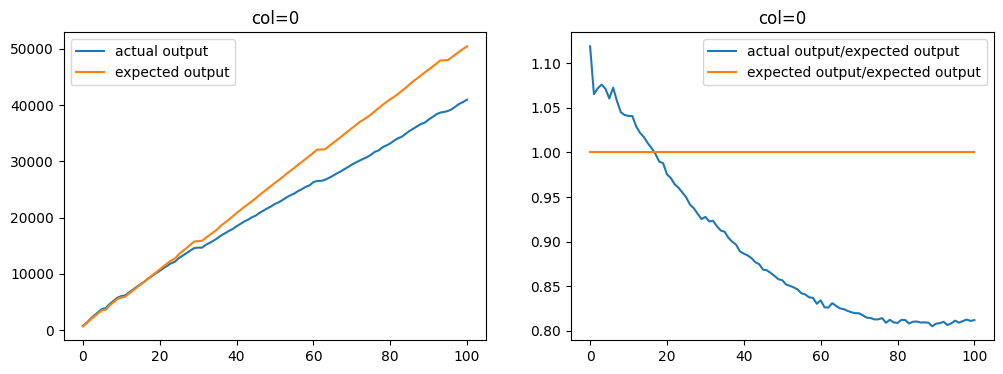

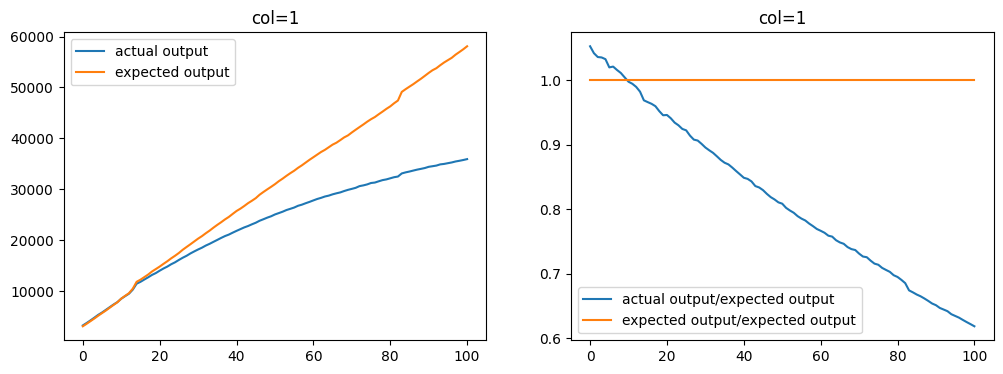

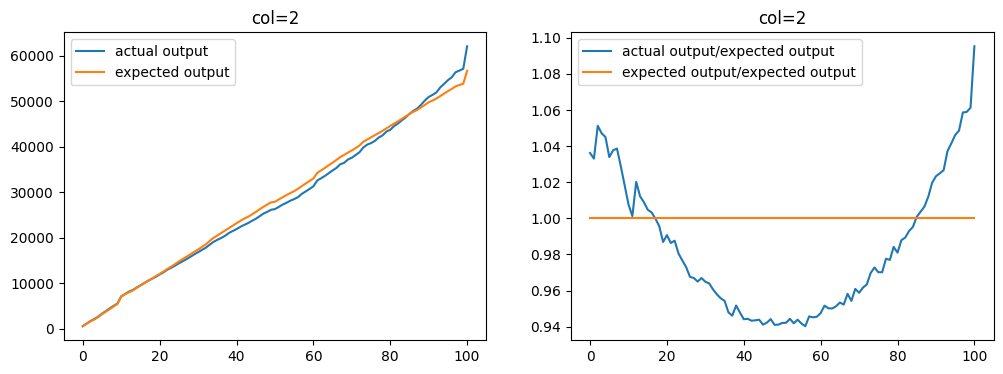

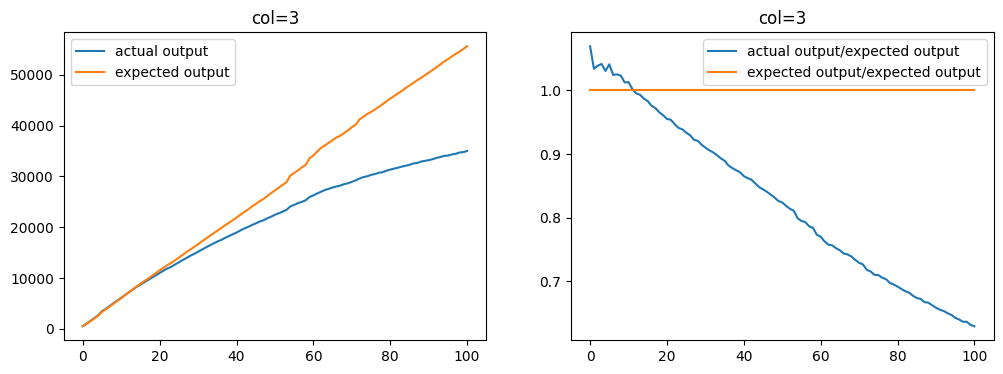

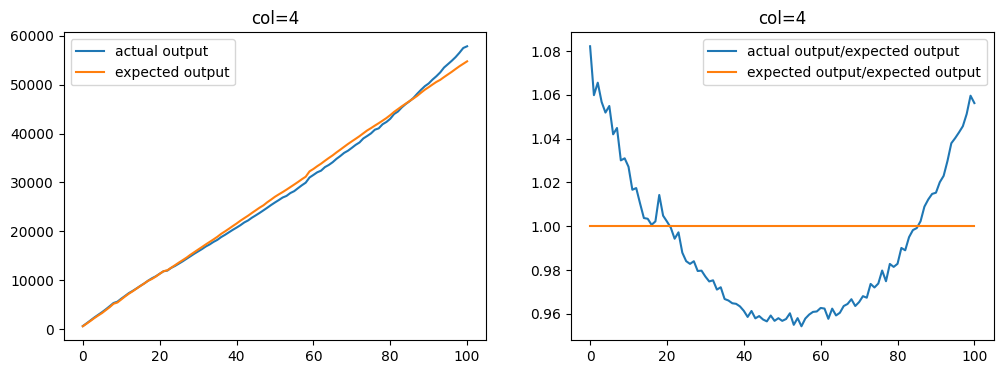

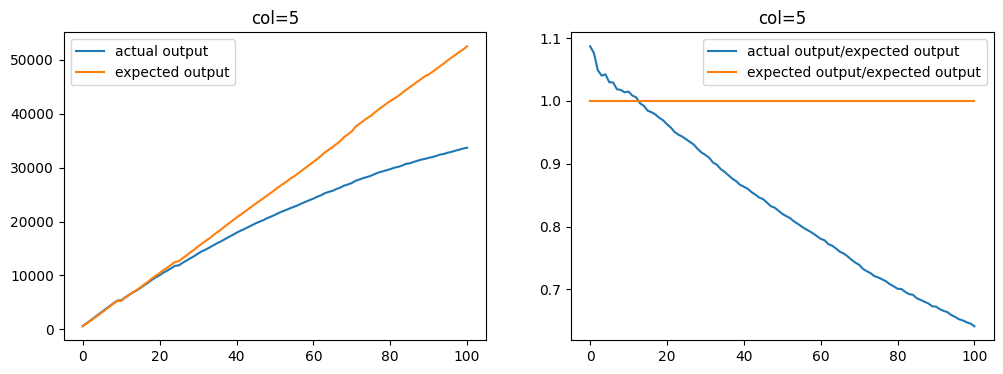

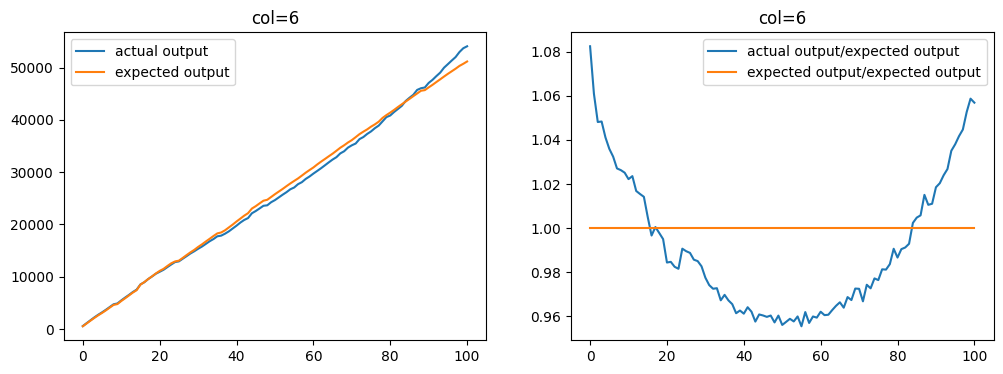

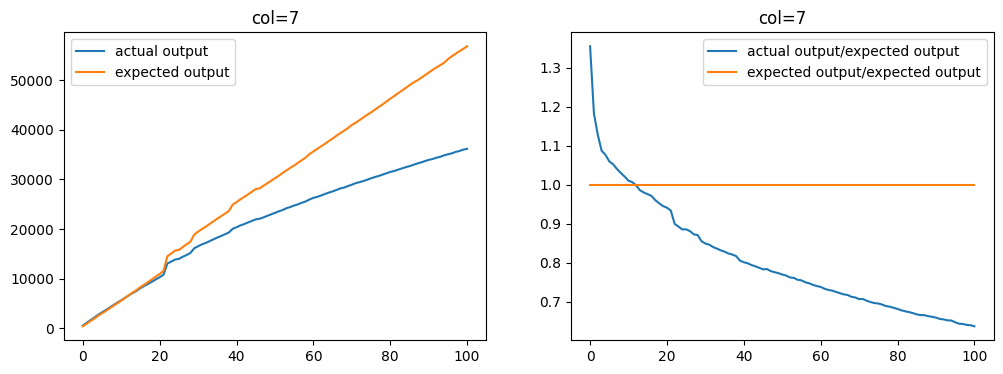

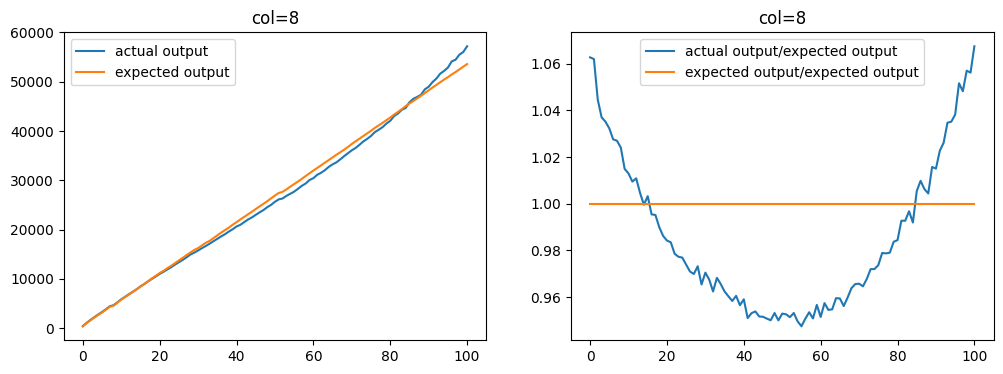

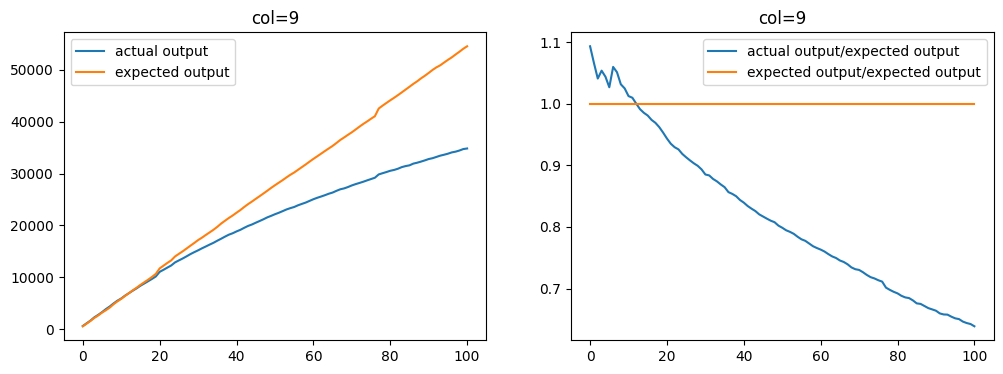

In [8]:
startpos,endpos = 0,101
num = 0
for num in range(10):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond_res[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"col={col_index[num]}")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(expected_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "expected output/expected output")
    plt.title(f"col={col_index[num]}")
    plt.legend()
    plt.show()

In [ ]:
# 10列，两路TIA并行
row_index = [10,11]
# 存储数据
real_res = np.zeros((256,len(row_index)))
expected_res = np.zeros((256,len(row_index)))

for i in range(256):
    col_index = [j for j in range(i+1)]

    _,cond,_ = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=4,row_type=0,col_type=0)

    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_col[pos],axis=1)
    real_res[i,:]=cond[row_index]

In [ ]:
pos = 4
plt.plot(real_res[startpos:,num].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,num].flatten(),label = "expected output")
plt.legend()
plt.show()

plt.plot(real_res[startpos:,1].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,1].flatten(),label = "expected output")
plt.legend()
plt.show()

In [ ]:
compensation_para:dict={
"value":0.5,
"real_mean":550,
"odd_offset":0,
"even_offset":0,
"odd_mult":1,
"even_mult":1,
"all_mult":1,
"add_wire":True
}

In [ ]:
# 10列，两路TIA并行
col_index = [10,11]
random_times = 200
select_num,total_num = 50,256
# 存储数据
real_res = np.zeros((random_times,len(col_index)))
expected_res = np.zeros((random_times,len(col_index)))

for i in range(random_times):
    rows_index = np.random.choice(total_num, select_num, replace=False)

    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(rows_index,res[2],from_row=True,return_type=0,compensation_para=compensation_para)
    # cond = res[1]
    # print(cond)
    pos = np.ix_(rows_index,col_index)
    expected_res[i,:]=np.sum(c[pos],axis=0)
    real_res[i,:]=cond[col_index]

In [ ]:
pos = 4
plt.plot(real_res[startpos:,num].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,num].flatten(),label = "expected output")
plt.legend()
plt.show()

plt.plot(real_res[startpos:,1].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,1].flatten(),label = "expected output")
plt.legend()
plt.show()

In [ ]:
pos = 4
plt.plot(real_res[startpos:,num].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,num].flatten(),label = "expected output")
plt.legend()
plt.show()

plt.plot(real_res[startpos:,1].flatten(),label = "actual output")
plt.plot(expected_res[startpos:,1].flatten(),label = "expected output")
plt.legend()
plt.show()